1 Setup libraries

In [ ]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from encoding import encode_columns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

2 Get file path

In [3]:

data_frame = pd.read_json(r"C:\Users\ADMIN\Documents\Algorithm_Inno\ML\data\data_labeled.json") #You Must use your data path not mine
data_frame.head()

,Transaction ID,Sender Account ID,Receiver Account ID,Transaction amount,Timestamp,Transaction Detail,Geological,Device Use,Date of Birth,Gender,Location,Account balance,Transaction Count,Working Status,Salary (per month),DateTime,Hour,DayOfWeek,is_fraud,anomaly_score
0,TXN_300001,ACC_04483,REC_7570,458000,2025-02-27 21:37:00,Starbucks,HCMC - VN,Android Phone,1996-08-12,Male,Hai Phong,79000000,3,Employed,13000000,2025-02-27 21:37:00,21,3,0,-0.442490
1,TXN_300002,ACC_04770,REC_8777,203000,2025-04-21 22:53:00,Starbucks,Can Tho - VN,Samsung S23,2004-06-17,Female,Bac Ninh,29000000,2,Employed,43000000,2025-04-21 22:53:00,22,0,0,-0.495491
2,TXN_300003,ACC_06821,REC_3980,1392000,2025-12-17 07:15:00,Restaurant,Hanoi - VN,Samsung S23,1992-05-07,Female,Hue,140000000,4,Employed,45000000,2025-12-17 07:15:00,7,2,0,-0.429954
3,TXN_300004,ACC_08825,REC_7662,11046000,2025-06-25 07:22:00,Monthly Salary,HCMC - VN,iPhone 15,1984-04-25,Female,Can Tho,21000000,2,Employed,29000000,2025-06-25 07:22:00,7,2,0,-0.472498
4,TXN_300005,ACC_03949,REC_6068,120000,2025-12-16 10:09:00,Restaurant,HCMC - VN,Web Browser,1976-10-05,Female,Bac Ninh,468000000,4,Unemployed,0,2025-12-16 10:09:00,10,1,0,-0.497311


3 Pick features

In [ ]:
text_columns = features.select_dtypes(include=['object']).columns.tolist()
if len(text_columns) > 0:
    print(f"-> Encoding columns: {text_columns}")
    features, _ = encode_columns(features.copy(), columns=text_columns)


4 Encode string to number

In [5]:
text_columns = features.select_dtypes(include=['object']).columns
if len(text_columns) > 0:
    print(f"-> Đang mã hóa các cột: {list(text_columns)}")
    for column in text_columns:
        encoder = LabelEncoder()
        features[column] = encoder.fit_transform(features[column].astype(str))
        


-> Đang mã hóa các cột: ['Transaction Detail', 'Geological', 'Device Use', 'Location', 'Working Status']


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9632\2239831300.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[column] = encoder.fit_transform(features[column].astype(str))
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9632\2239831300.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features[column] = encoder.fit_transform(features[column].astype(str))
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9632\2239831300.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

5 Train model

In [6]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
#80% train 20% test

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


6 Evaluate

In [7]:
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, predictions, target_names=['Normal', 'Fraud']))
    

Accuracy: 0.9918
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00      4244
       Fraud       0.97      0.98      0.97       756

    accuracy                           0.99      5000
   macro avg       0.98      0.99      0.98      5000
weighted avg       0.99      0.99      0.99      5000



7 Show importances impact to Detection 

In [8]:
feature_names = [
    'Transaction amount', 'Account balance', 'Salary (per month)', 
    'Hour', 'DayOfWeek', 'Transaction Detail', 
    'Geological', 'Device Use', 'Location', 'Working Status'
]

importance_df = pd.DataFrame({
    'Features': feature_names, 
    'Importances': model.feature_importances_
}).sort_values('Importances', ascending=False)

# Hiển thị kết quả
print(importance_df.head(5))


             Features  Importances
0  Transaction amount     0.398376
1     Account balance     0.283406
3                Hour     0.113302
2  Salary (per month)     0.104811
6          Geological     0.052658


8 Visualization


8.1 Feature Importance Bar Chart (most important)
    Visualize top 5 importance

Text(0.5, 0, 'Importance Score')

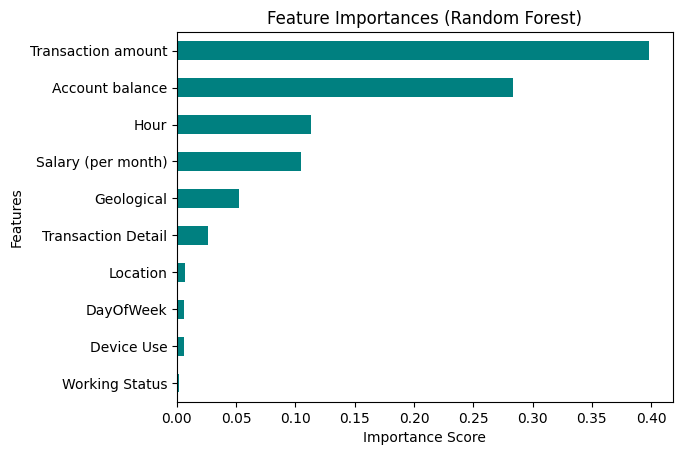

In [9]:
import matplotlib.pyplot as plt

importance_df.sort_values('Importances').plot(kind='barh', x='Features', y='Importances', legend=False, color='teal')
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Importance Score')

5.2 Confusion Matrix
    Shows true positives, false positives, etc. — critical for fraud detection where false negatives are costly.

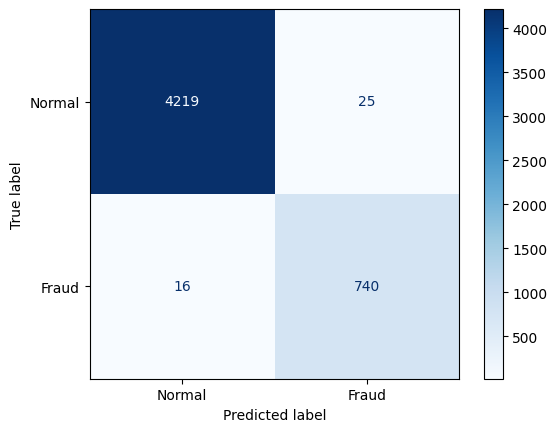

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=['Normal','Fraud'], cmap='Blues')

3. ROC Curve
Visualizes the trade-off between catching fraud (recall) vs. false alarms (false positive rate).

Text(0.5, 1.0, 'ROC Curve - Random Forest')

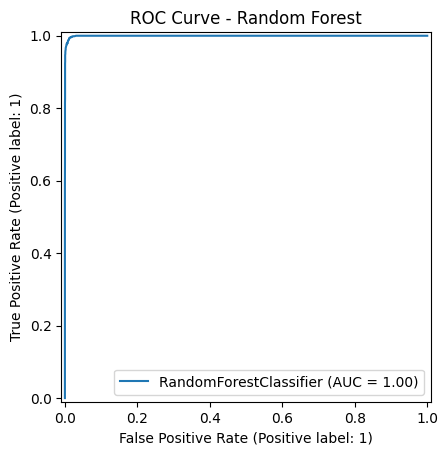

In [11]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('ROC Curve - Random Forest')

4. Precision-Recall Curve
More informative than ROC for imbalanced datasets like fraud detection (few fraud vs many normal).

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
plt.title('Precision-Recall Curve')

5. Single Tree Visualization (optional/impressive)
Visualize one of the 100 trees to understand decision logic.

[Text(0.5431034482758621, 0.9, 'Account balance <= 506000000.0\ngini = 0.251\nsamples = 12681\nvalue = [17061, 2939]\nclass = Normal'),
 Text(0.27586206896551724, 0.7, 'Geological <= 5.5\ngini = 0.047\nsamples = 10999\nvalue = [16967, 414]\nclass = Normal'),
 Text(0.40948275862068967, 0.8, 'True  '),
 Text(0.13793103448275862, 0.5, 'Transaction Detail <= 1.5\ngini = 0.019\nsamples = 10823\nvalue = [16930, 168]\nclass = Normal'),
 Text(0.06896551724137931, 0.3, 'Salary (per month) <= 7500000.0\ngini = 0.043\nsamples = 31\nvalue = [1, 45]\nclass = Fraud'),
 Text(0.034482758620689655, 0.1, '\n  (...)  \n'),
 Text(0.10344827586206896, 0.1, '\n  (...)  \n'),
 Text(0.20689655172413793, 0.3, 'Geological <= 0.5\ngini = 0.014\nsamples = 10792\nvalue = [16929, 123]\nclass = Normal'),
 Text(0.1724137931034483, 0.1, '\n  (...)  \n'),
 Text(0.2413793103448276, 0.1, '\n  (...)  \n'),
 Text(0.41379310344827586, 0.5, 'Transaction amount <= 228892000.0\ngini = 0.227\nsamples = 176\nvalue = [37.0, 246.0

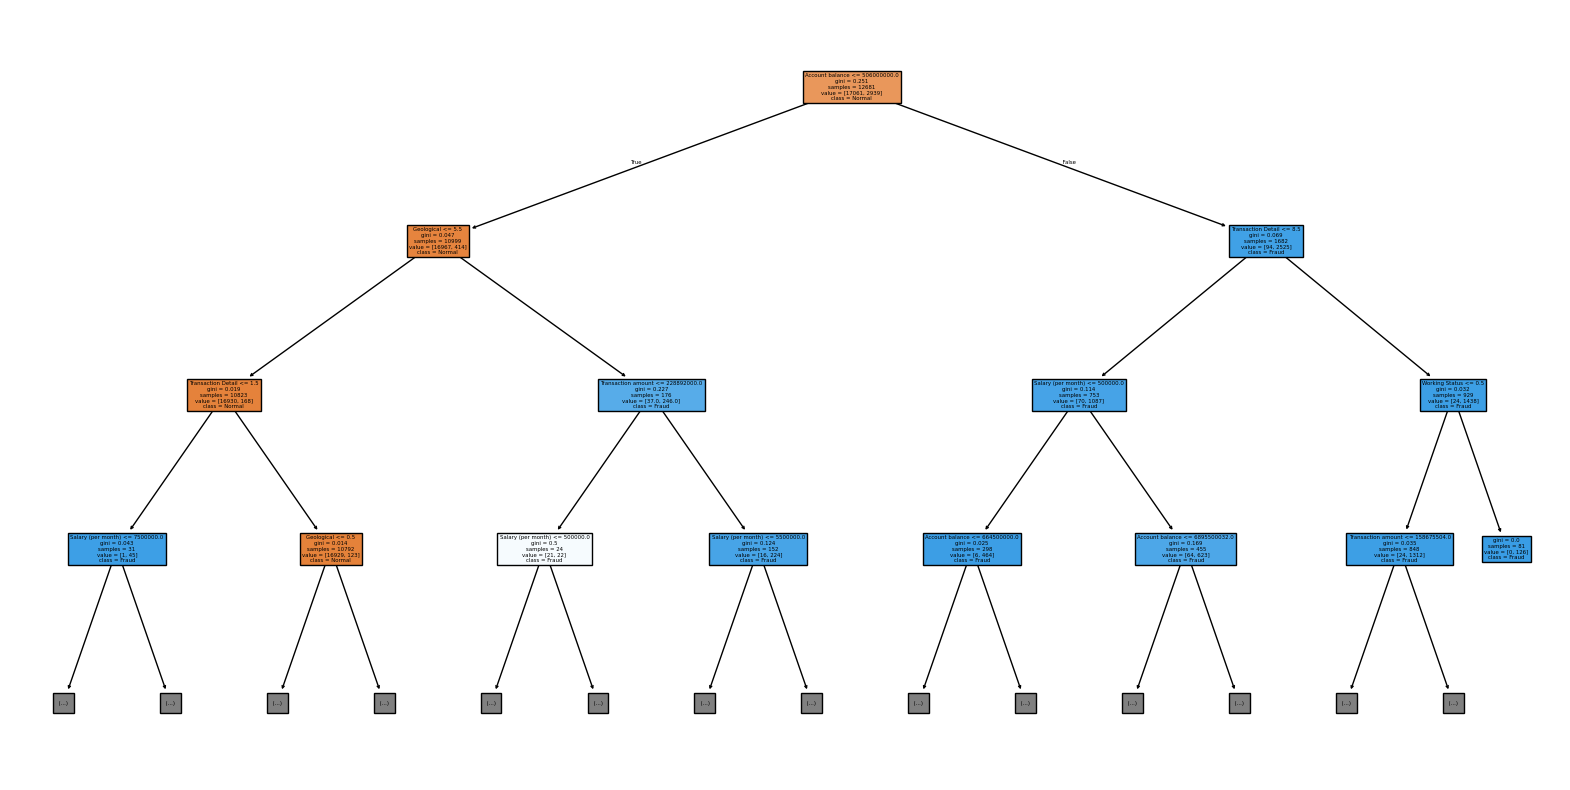

In [12]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model.estimators_[0], feature_names=feature_columns, class_names=['Normal','Fraud'], max_depth=3, filled=True)